In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import shap
import warnings
warnings.filterwarnings("ignore")

In [5]:
df = pd.read_csv("telco.csv")
df.head()

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


In [6]:
# Remove spaces in column names
df.columns = df.columns.str.replace(" ", "")

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Fill missing values
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

0         39.65
1        633.30
2       1752.55
3       2514.50
4       2868.15
         ...   
7038    1419.40
7039    1990.50
7040    7362.90
7041     346.45
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

In [7]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   CustomerID                     7043 non-null   str    
 1   Gender                         7043 non-null   str    
 2   Age                            7043 non-null   int64  
 3   Under30                        7043 non-null   str    
 4   SeniorCitizen                  7043 non-null   str    
 5   Married                        7043 non-null   str    
 6   Dependents                     7043 non-null   str    
 7   NumberofDependents             7043 non-null   int64  
 8   Country                        7043 non-null   str    
 9   State                          7043 non-null   str    
 10  City                           7043 non-null   str    
 11  ZipCode                        7043 non-null   int64  
 12  Latitude                       7043 non-null   float64
 13 

,Age,NumberofDependents,ZipCode,Latitude,Longitude,Population,NumberofReferrals,TenureinMonths,AvgMonthlyLongDistanceCharges,AvgMonthlyGBDownload,MonthlyCharge,TotalCharges,TotalRefunds,TotalExtraDataCharges,TotalLongDistanceCharges,TotalRevenue,SatisfactionScore,ChurnScore,CLTV
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,46.509726,0.468692,93486.070567,36.197455,-119.756684,22139.603294,1.951867,32.386767,22.958954,20.515405,64.761692,2280.381264,1.962182,6.860713,749.099262,3034.379056,3.244924,58.505040,4400.295755
std,16.750352,0.962802,1856.767505,2.468929,2.154425,21152.392837,3.001199,24.542061,15.448113,20.418940,30.090047,2266.220462,7.902614,25.104978,846.660055,2865.204542,1.201657,21.170031,1183.057152
min,19.000000,0.000000,90001.000000,32.555828,-124.301372,11.000000,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.000000,0.000000,0.000000,21.360000,1.000000,5.000000,2003.000000
25%,32.000000,0.000000,92101.000000,33.990646,-121.788090,2344.000000,0.000000,9.000000,9.210000,3.000000,35.500000,400.150000,0.000000,0.000000,70.545000,605.610000,3.000000,40.000000,3469.000000
50%,46.000000,0.000000,93518.000000,36.205465,-119.595293,17554.000000,0.000000,29.000000,22.890000,17.000000,70.350000,1394.550000,0.000000,0.000000,401.440000,2108.640000,3.000000,61.000000,4527.000000
75%,60.000000,0.000000,95329.000000,38.161321,-117.969795,36125.000000,3.000000,55.000000,36.395000,27.000000,89.850000,3786.600000,0.000000,0.000000,1191.100000,4801.145000,4.000000,75.500000,5380.500000
max,80.000000,9.000000,96150.000000,41.962127,-114.192901,105285.000000,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000,5.000000,96.000000,6500.000000


In [8]:

leakage_cols = [
    "ChurnScore",
    "CLTV",
    "ChurnReason",
    "CustomerStatus",
    "SatisfactionScore",
    "TotalRevenue"
]

for col in leakage_cols:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)

In [9]:
if "CustomerID" in df.columns:
    df.drop("CustomerID", axis=1, inplace=True)

In [10]:
X = df.drop("ChurnLabel", axis=1)
y = df["ChurnLabel"]

In [11]:
X = pd.get_dummies(X, drop_first=True)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
from sklearn.utils import resample

# Combine X_train and y_train
train_data = pd.concat([X_train, y_train], axis=1)

# Separate classes
churn_yes = train_data[train_data.ChurnLabel == 'Yes']
churn_no = train_data[train_data.ChurnLabel == 'No']

# Upsample minority class
churn_yes_upsampled = resample(
    churn_yes,
    replace=True,
    n_samples=len(churn_no),
    random_state=42
)

# Combine
balanced_data = pd.concat([churn_no, churn_yes_upsampled])

# Split again
X_train = balanced_data.drop("ChurnLabel", axis=1)
y_train = balanced_data["ChurnLabel"]

In [14]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
svm_model = SVC(probability=True)
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)
svm_model.fit(X_train_scaled, y_train)
rf_model.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [16]:
svm_pred = svm_model.predict(X_test_scaled)
rf_pred = rf_model.predict(X_test_scaled)

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))
print("RF Accuracy:", accuracy_score(y_test, rf_pred))

SVM Accuracy: 0.7991483321504613
RF Accuracy: 0.8573456352022711


In [17]:

from sklearn.model_selection import cross_val_predict

svm_train_prob = cross_val_predict(
    svm_model, X_train_scaled, y_train,
    cv=5, method='predict_proba'
)[:, 1]

rf_train_prob = cross_val_predict(
    rf_model, X_train_scaled, y_train,
    cv=5, method='predict_proba'
)[:, 1]

meta_X_train = np.column_stack((svm_train_prob, rf_train_prob))
meta_model = LogisticRegression()
meta_model.fit(meta_X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [19]:
svm_test_prob = svm_model.predict_proba(X_test_scaled)[:, 1]
rf_test_prob = rf_model.predict_proba(X_test_scaled)[:, 1]

meta_X_test = np.column_stack((svm_test_prob, rf_test_prob))

final_pred = meta_model.predict(meta_X_test)

print("Final Stacking Accuracy:", accuracy_score(y_test, final_pred))
print(confusion_matrix(y_test, final_pred))
print(classification_report(y_test, final_pred))

Final Stacking Accuracy: 0.8701206529453513
[[932  77]
 [106 294]]
              precision    recall  f1-score   support

          No       0.90      0.92      0.91      1009
         Yes       0.79      0.73      0.76       400

    accuracy                           0.87      1409
   macro avg       0.85      0.83      0.84      1409
weighted avg       0.87      0.87      0.87      1409



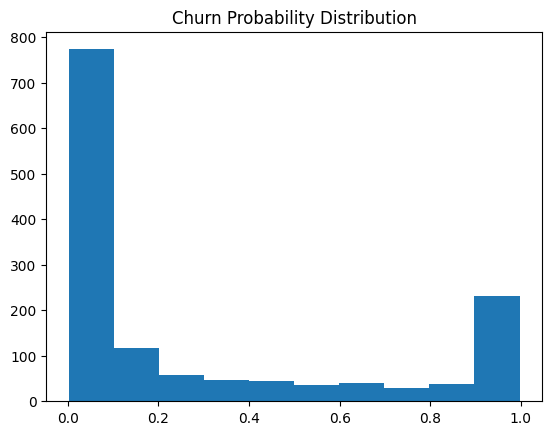

In [20]:
import matplotlib.pyplot as plt

probs = meta_model.predict_proba(meta_X_test)[:,1]

plt.hist(probs)
plt.title("Churn Probability Distribution")
plt.show()

In [21]:
def recommend_action(prob):
    if prob > 0.75:
        return "High Risk - Give Discount Offer"
    elif prob > 0.5:
        return "Medium Risk - Call Customer"
    else:
        return "Low Risk - No Action"

In [22]:
explainer = shap.TreeExplainer(rf_model)

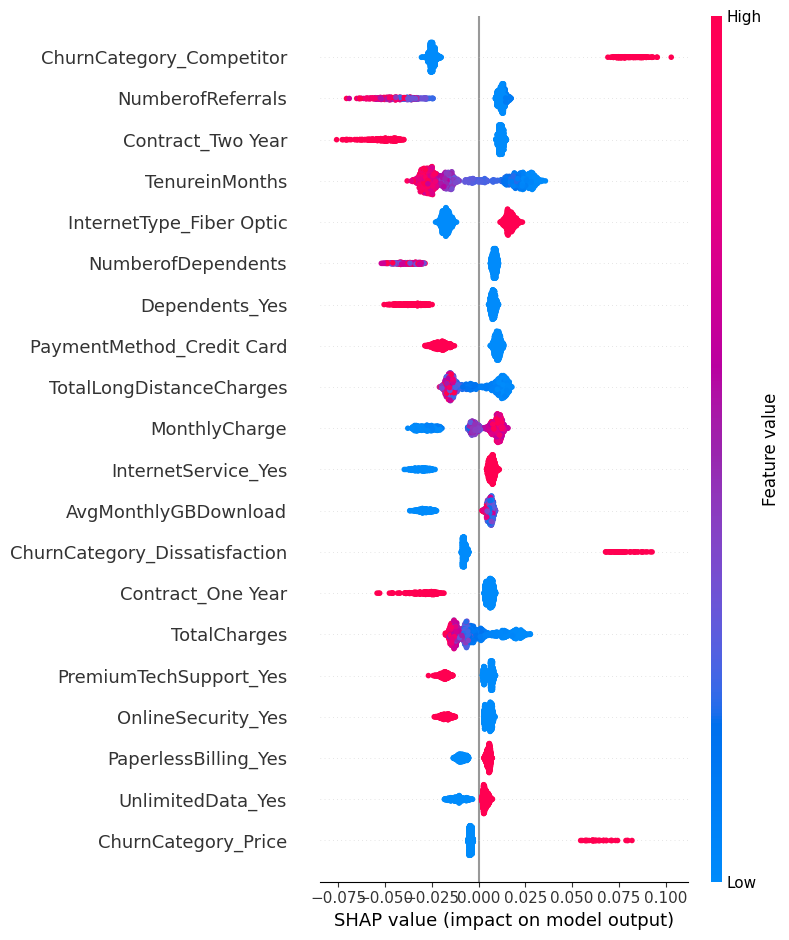

In [23]:
shap_values = explainer.shap_values(X_test_scaled)
shap.summary_plot(shap_values[:, :, 1], X_test)

In [24]:
def shap_explanation(new_scaled):
    shap_vals = explainer.shap_values(new_scaled)
    shap_vals = shap_vals[:, :, 1]

    feature_importance = dict(zip(X.columns, shap_vals[0]))
    sorted_features = sorted(feature_importance.items(), key=lambda x: abs(x[1]), reverse=True)

    return sorted_features[:5]

In [25]:
reason_map = {
    'TenureinMonths': 'Customer tenure is low',
    'MonthlyCharges': 'Monthly charges are high',
    'TotalCharges': 'Customer is new (low total charges)',
    'InternetType_Fiber Optic': 'Customer uses expensive fiber plan',
    'Contract_Two Year': 'Customer has long-term contract',
    'OnlineSecurity_Yes': 'Customer has online security',
    'TechSupport_Yes': 'Customer has tech support',
    'NumberofReferrals': 'Customer referred fewer people',
    'PremiumTechSupport_Yes': 'Customer has premium tech support',
    'ChurnCategory_Competitor': 'Customer is attracted by competitor offers'
}

In [26]:
def predict_customer(new_customer_dict):
    import pandas as pd
    import numpy as np

    # Convert to DataFrame
    new_df = pd.DataFrame([new_customer_dict])

    # Align columns with training data
    new_df = new_df.reindex(columns=X.columns, fill_value=0)

    # Scale
    new_scaled = scaler.transform(new_df)

    # Base model probabilities
    svm_prob = svm_model.predict_proba(new_scaled)[:,1]
    rf_prob = rf_model.predict_proba(new_scaled)[:,1]

    # Meta model
    meta_input = np.column_stack((svm_prob, rf_prob))
    final_prob = meta_model.predict_proba(meta_input)[:,1][0]

    # Business decision
    if final_prob >= 0.75:
        action = "High Risk - Give Discount"
    elif final_prob >= 0.45:
        action = "Medium Risk - Personalized Offer"
    else:
        action = "Low Risk - No Action"

    # SHAP values
    shap_values = explainer.shap_values(new_scaled)
    shap_val = shap_values[:,:,1][0]

    feature_importance = sorted(
        zip(X.columns, shap_val),
        key=lambda x: abs(x[1]),
        reverse=True
    )[:5]
    threshold = 0.02
    feature_importance = [
    (f, v) for f, v in feature_importance if abs(v) > threshold
    ]

    # =========================
    # SMART REASON GENERATOR
    # =========================

    feature_impact = {
        'TenureinMonths': 'low',
        'MonthlyCharges': 'high',
        'TotalCharges': 'low',
        'InternetType_Fiber Optic': 'high',
        'Contract_Two year': 'good',
        'Contract_One year': 'good',
        'OnlineSecurity_Yes': 'good',
        'TechSupport_Yes': 'good',
        'NumberofReferrals': 'low',
        'PremiumTechSupport_Yes': 'good',
        'ChurnCategory_Competitor': 'high'
    }

    reason_map = {
        'TenureinMonths': 'Customer tenure',
        'MonthlyCharges': 'Monthly charges',
        'TotalCharges': 'Total spending',
        'InternetType_Fiber Optic': 'Fiber internet plan',
        'Contract_Two year': 'Long-term contract',
        'Contract_One year': 'Yearly contract',
        'OnlineSecurity_Yes': 'Online security',
        'TechSupport_Yes': 'Tech support',
        'NumberofReferrals': 'Customer referrals',
        'PremiumTechSupport_Yes': 'Premium support',
        'ChurnCategory_Competitor': 'Competitor influence'
    }

    readable_reasons = []

    for feature, value in feature_importance:
        if feature in reason_map:
            impact_type = feature_impact.get(feature, 'neutral')
            feature_name = reason_map[feature]

            if value > 0:
                if impact_type in ['low', 'bad']:
                    readable_reasons.append(f"Risk Increase: Low {feature_name}")
                elif impact_type == 'high':
                    readable_reasons.append(f"Risk Increase: High {feature_name}")
                else:
                    readable_reasons.append(f"Risk Increase: {feature_name}")
            else:
                if impact_type == 'good':
                    readable_reasons.append(f"Risk Decrease: Strong {feature_name}")
                elif impact_type == 'high':
                    readable_reasons.append(f"Risk Decrease: Low {feature_name}")
                elif impact_type == 'low':
                    readable_reasons.append(f"Risk Decrease: High {feature_name}")
                else:
                    readable_reasons.append(f"Risk Decrease: {feature_name}")
    if final_prob >= 0.75:
        readable_reasons = [r for r in readable_reasons if "Increase" in r]
    elif final_prob < 0.45:
        readable_reasons = [r for r in readable_reasons if "Decrease" in r]
    
    # Optional: keep only top 3
    readable_reasons = readable_reasons[:3]

    return final_prob, action, readable_reasons

In [27]:
base_customer = X.mean().to_frame().T

In [28]:
cust_high = base_customer.copy()

cust_high['TenureinMonths'] = 2
cust_high['MonthlyCharges'] = 95
cust_high['TotalCharges'] = 150

# Risk conditions
for col in cust_high.columns:
    if 'Contract_Two year' in col:
        cust_high[col] = 0
    if 'Contract_One year' in col:
        cust_high[col] = 0
    if 'OnlineSecurity_Yes' in col:
        cust_high[col] = 0
    if 'TechSupport_Yes' in col:
        cust_high[col] = 0
    if 'InternetType_Fiber Optic' in col:
        cust_high[col] = 1

In [29]:
cust_low = base_customer.copy()

cust_low['TenureinMonths'] = 70
cust_low['MonthlyCharges'] = 35
cust_low['TotalCharges'] = 2500

# Safe conditions
for col in cust_low.columns:
    if 'Contract_Two year' in col:
        cust_low[col] = 1
    if 'OnlineSecurity_Yes' in col:
        cust_low[col] = 1
    if 'TechSupport_Yes' in col:
        cust_low[col] = 1
    if 'InternetType_Fiber Optic' in col:
        cust_low[col] = 0

In [30]:
prob1, action1, reasons1 = predict_customer(cust_high.iloc[0].to_dict())
prob2, action2, reasons2 = predict_customer(cust_low.iloc[0].to_dict())

print("High Risk Customer:", prob1, action1)
print("Reasons:", reasons1)

print("\nLow Risk Customer:", prob2, action2)
print("Reasons:", reasons2)

High Risk Customer: 0.783478944117905 High Risk - Give Discount
Reasons: ['Risk Increase: Low Customer tenure']

Low Risk Customer: 0.02409057459679316 Low Risk - No Action
Reasons: ['Risk Decrease: High Customer referrals', 'Risk Decrease: High Customer tenure', 'Risk Decrease: Low Competitor influence']


In [31]:
import pickle

pickle.dump(svm_model, open("svm_model.pkl", "wb"))
pickle.dump(rf_model, open("rf_model.pkl", "wb"))
pickle.dump(meta_model, open("meta_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))
pickle.dump(explainer, open("explainer.pkl", "wb"))

print("Models saved successfully!")

Models saved successfully!


In [32]:
import pickle

# Save column names used during training
pickle.dump(X_train.columns, open("model_columns.pkl", "wb"))

print("Column names saved!")

Column names saved!


In [33]:
import pickle

# Save column names as LIST (not pandas index)
pickle.dump(list(X_train.columns), open("model_columns.pkl", "wb"))

print("Columns saved as list!")

Columns saved as list!


In [34]:
import pickle

base_customer = X.mean().to_frame().T
pickle.dump(base_customer, open("base_customer.pkl", "wb"))

print("Base customer saved")

Base customer saved


In [35]:
import pickle

base_customer_dict = X.mean().to_dict()

pickle.dump(base_customer_dict, open("base_customer.pkl", "wb"))

print("Base customer dictionary saved")

Base customer dictionary saved


In [40]:
import shap
import pickle

# Take sample data
X_sample = X_train.sample(100, random_state=42)

explainer = shap.TreeExplainer(rf_model)

# Save explainer
pickle.dump(explainer, open("explainer.pkl", "wb"))

print("SHAP Explainer saved")

SHAP Explainer saved
